# Bonus Quest

**Difficulty:** A

**Description:** Students are in a tough spot after changing the grading formula for assignments and now fear taking the exam without a 3.5 GPA. The system gives players a chance to raise their score by completing this bonus quest. This is your Solo Leveling. Survive at all costs. Good luck!

**Goal:** Complete the bonus assignment created by Andrei and corrected by Max.

**Deliverables:**
- Jupyter Notebook (ipynb) file with solution and all cell outputs
- CSV file with model predictions
- Both files uploaded to GitHub repository

**Reward:**
- Bonus points for the Assignment part.
- Title “The one who overcomes the difficulties of fate.”
- +1000 EXP in mastering sklearn
- Skill Upgrade «ML Engineering Lv.2»
- Special Item: [???]

---

## Problem Statement

As a dataset, use Russian news from Balto-Slavic Natural Language Processing 2019 (helsinki.fi). Entities of interest: PER, ORG, LOC, EVT, PRO (see Guidelines_20190122.pdf (helsinki.fi)).

It is sufficient to use 9 documents about Brexit from the sample provided by the organizers.

## Approach

This assignment combines traditional ML methods (using scikit-learn) with modern LLM-based approaches (DeepSeek) for comparison. You will:
1. Formulate the problem as a machine learning task
2. Prepare features and split data appropriately
3. Train and compare multiple models using scikit-learn
4. Evaluate models using proper train/test splits
5. Compare ML model performance with DeepSeek responses
6. Analyze results in terms of course concepts (bias-variance tradeoff, overfitting, generalization)


Example of one document:

ru-10

ru

2018-09-20

https://rg.ru/2018/09/20/tereza-mej-rasschityvaet-usidet-v-sedle-do-zaversheniia-procedury-brexit.html

Theresa May expects to stay in the saddle until the completion of the Brexit procedure
However, according to British media reports, at the upcoming Conservative Party conference at the end of September, May's opponents will give her a serious fight, from which it is not certain that she will emerge victorious. The bookmakers' favorite as a possible replacement for the current prime minister, former British Foreign Secretary Boris Johnson intends to deliver an alternative report that will leave no stone unturned from the government's views on the conditions of "Brexit". From Johnson's point of view, "London has wrapped the British constitution in a suicide belt and handed the detonator to Michel Barnier (Brussels' chief Brexit negotiator. - Ed.)". It is with this metaphor that the head of the British government will have to fight at the conference.


### Task 1
**Problem Formulation & ML Perspective**

Describe the task from both NLP and ML perspectives:
- What kind of machine learning problem is this? (classification, sequence labeling, etc.)
- How can this be formulated as a supervised learning problem?
- What classical ML methods exist for solving it? (e.g., logistic regression, naive Bayes, SVM with text features)
- How can it be solved using modern LLMs like DeepSeek?
- What are the assumptions of different model classes? (e.g., linear models vs. more complex approaches)
- How is model quality typically evaluated in this task? What metrics are appropriate and why?


- Это задача распознавания именованных сущностей (Named Entity Recognition, NER). Конкретно требуется:

  - Выделить в тексте слова/словосочетания, относящиеся к пяти классам сущностей: PER (person), ORG (organization), LOC (location), EVT (event), PRO (product).
  -  Присвоить им правильный тип.
- Это задача обучения с учителем, где входными данными является предложение или фрагмент текста, а выходными данными — метки сущностей в этом предложении. Нужны размеченные данные, где для каждого токена (или их последовательности) в тексте известно, к какому классу он относится, с какой меткой. Алгоритм обучается на таких примерах, чтобы предсказывать метки для новых, неразмеченных токенов.

-
  - Логистическая регрессия (Logistic Regression): может использоваться для классификации каждого токена после извлечения признаков (слова, части речи, регистр)
  - Наивный Байес:  предсказывает метки сущностей для каждого токена на основе вероятностей с предположением о независимости признаков
  -Условные случайные поля: моделирует зависимость между соседними метками в последовательности, это повышает точность

-
  - Прямой запрос: ввод текста с инструкцией извлечь сущности указанных типов
  - LLM могут быть дообучены на специфическом наборе данных для NER, что обычно дает наилучшие результаты.
-
  - Линейные модели предполагают, что признаки и взаимосвязи между метками в последовательности можно хорошо разделить линейной функцией, признаки независимы

- Для оценки качества NER можно использовать:
  -   Precision (Точность): Доля правильно извлеченных сущностей из всех сущностей, извлеченных моделью. Важно для минимизации ложных срабатываний.
  -   Recall (Полнота): Доля правильно извлеченных сущностей из всех истинных. Важно для минимизации пропущенных сущностей.
  -   F1-Score (F-мера): Гармоническое среднее Precision и Recall. Обеспечивает сбалансированную оценку, особенно полезно при дисбалансе классов.
  -   Accuracy (Аккуратность): Доля правильно классифицированных токенов. Менее информативна для NER, так как класса "O" (не сущность) обычно больше всего, из-за чего высокий Accuracy может скрывать плохую производительность на классах сущностей.

### Task 2
**Data Loading & Preparation**

Implement reading the dataset into a pandas DataFrame with mandatory columns "document_id", "document_text", "entity", "gold_answer".

Then prepare the data for ML:
- Create features from text (e.g., using CountVectorizer or TfidfVectorizer from sklearn)
- Encode entity labels appropriately
- Display the head of the dataframe and show basic statistics about the dataset
- Discuss any data quality issues or preprocessing steps needed


Первые 5 строк DataFrame:
  document_id                                      document_text entity  \
0          10  Тереза Мэй рассчитывает усидеть в седле до зав...    EVT   
1          10  Тереза Мэй рассчитывает усидеть в седле до зав...    LOC   
2          10  Тереза Мэй рассчитывает усидеть в седле до зав...    LOC   
3          10  Тереза Мэй рассчитывает усидеть в седле до зав...    PER   
4          10  Тереза Мэй рассчитывает усидеть в седле до зав...    LOC   

     gold_answer  
0         Brexit  
1       Альбиона  
2       Альбионе  
3  Борис Джонсон  
4       Британии  
Основная информация о данных:
Количество документов: 9
Длина документов: 
 avg=2166, 
 min=436.0, 
 max=5160.0
Количество сущностей: 5
Распределение сущностей:
entity
PER    63
ORG    36
LOC    36
EVT    13
PRO     5
Name: count, dtype: int64
Закодированные метки сущностей:
EVT: 0
LOC: 1
ORG: 2
PER: 3
PRO: 4


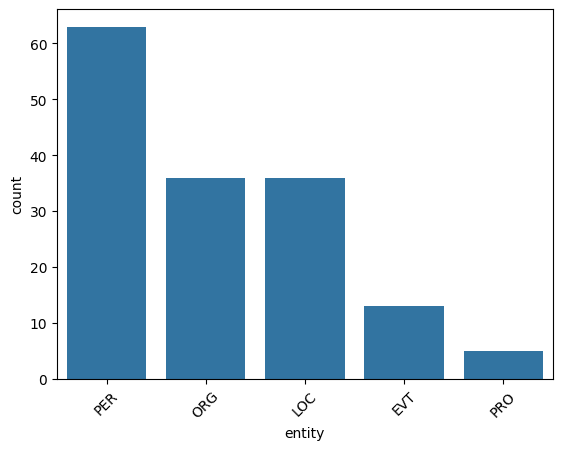

Первые 5 строк DataFrame c контекстом:
  document_id                                      document_text entity  \
0          10  Тереза Мэй рассчитывает усидеть в седле до зав...    EVT   
1          10  Тереза Мэй рассчитывает усидеть в седле до зав...    LOC   
2          10  Тереза Мэй рассчитывает усидеть в седле до зав...    LOC   
3          10  Тереза Мэй рассчитывает усидеть в седле до зав...    PER   
4          10  Тереза Мэй рассчитывает усидеть в седле до зав...    LOC   

     gold_answer                                            context  
0         Brexit  в седле до завершения процедуры Brexit Тем не ...  
1       Альбиона  сражаться на конференции главе правительства А...  
2       Альбионе  приходом Джонсона к власти на Альбионе: ведь в...  
3  Борис Джонсон  бывший министр иностранных дел Британии Борис ...  
4       Британии  премьера, бывший министр иностранных дел Брита...  
Размерность TF-IDF признаков: (153, 257)
Количество закодированных меток: 153


In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Нашли данные, поместили в github и из него же загружаются в самом коде https://github.com/AlinaLar3/data_brexit
base_url_raw = "https://raw.githubusercontent.com/AlinaLar3/data_brexit/main/raw/"
base_url_ann = "https://raw.githubusercontent.com/AlinaLar3/data_brexit/main/ann/"

file_ids = [
    "brexit_ru.txt_file_10",
    "brexit_ru.txt_file_1000",
    "brexit_ru.txt_file_1001",
    "brexit_ru.txt_file_1002",
    "brexit_ru.txt_file_1003",
    "brexit_ru.txt_file_1004",
    "brexit_ru.txt_file_1006",
    "brexit_ru.txt_file_1011",
    "brexit_ru.txt_file_1017"
]

# Извлечение текста
def parse_txt(txt):
    lines = txt.strip().split('\n')
    text_lines = lines[4:]
    return ' '.join(text_lines).strip()

# Извлечение данных готовых сущностей
def parse_out(out, doc_id):
    result = []
    lines = out.strip().split('\n')
    for line in lines:
        parts = line.split('\t')
        if len(parts) == 4:
            gold_answer, lemma, entity_type, res = parts
            result.append({
                'document_id': doc_id,
                'gold_answer': gold_answer,
                'entity_type': entity_type,
            })
    return result

data = []

for file_id in file_ids:
    txt_file = requests.get(base_url_raw + file_id + ".txt").text
    out_file = requests.get(base_url_ann + file_id + ".out").text
    doc_text = parse_txt(txt_file)
    doc_id = file_id.split('_')[-1]
    entities = parse_out(out_file, doc_id)
    # Для будущего DataFrame
    for ent in entities:
        data.append({
            'document_id': ent['document_id'],
            'document_text': doc_text,
            'entity': ent['entity_type'],
            'gold_answer': ent['gold_answer']
        })

df = pd.DataFrame(data, columns=['document_id', 'document_text', 'entity', 'gold_answer']) # Сам DataFrame

# Кодировка
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['entity'])

print("Первые 5 строк DataFrame:")
print(df.head())
print("Основная информация о данных:")
print(f"Количество документов: {df['document_id'].nunique()}")
text_stats = df['document_text'].str.len().describe()
print(f"Длина документов: \n avg={text_stats['mean']:.0f}, \n min={text_stats['min']}, \n max={text_stats['max']}")
print(f"Количество сущностей: {df['entity'].nunique()}")
print("Распределение сущностей:")
print(df['entity'].value_counts())
print("Закодированные метки сущностей:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")
sns.countplot(data=df, x='entity', order=df['entity'].value_counts().index); plt.xticks(rotation=45); plt.show()

# Проблемы с качеством данных или необходимые этапы предварительной обработки:
# * Текст документа полностью дублируется для каждой сущности в нём, нужно сократить до окружения сущности для лучшего процесса обучения
# Классы несбалансированы
# Должны учитываться разные формы слова из-за падежных окончаний
# Маленький объём данных
# Сущности не только из одного слова

# * Добавим столбец с контекстом/окружением каждой сущности
# Очистить от знаков препинания (мешают найти сущность из-за неполного совпадения)
def clean_words(s):
    for p in '.,!?;:"()[]{}«»„“':
        s = s.replace(p, ' ')
    return s.lower().split()
def get_context(text, entity_phrase, numb=5): # число слов до и после сущности
    text_words = clean_words(text)
    entity_words = clean_words(entity_phrase)
    if len(entity_words) > 1:
        # Ищем последовательность слов
        for i in range(len(text_words) - len(entity_words) + 1):
            if text_words[i:i+len(entity_words)] == entity_words:
                start = max(0, i - numb)
                end = min(len(text_words), i + len(entity_words) + numb)
                # Восстанавливаем оригинальные слова из текста
                original_words = text.split()
                # Сопоставление позиций
                start_orig = max(0, i - numb)
                end_orig = min(len(original_words), i + len(entity_words) + numb)
                return ' '.join(original_words[start_orig:end_orig])
    # Ищем одиночное слово или если не нашли последовательность
    for i, word in enumerate(text_words):
        for e_word in entity_words:
            if word == e_word:
                # Восстанавливаем оригинальные слова из текста
                original_words = text.split()
                # Сопоставление позиций
                start = max(0, i - numb)
                end = min(len(original_words), i + numb + 1)
                return ' '.join(original_words[start:end])
    # Если не нашли, возвращаем весь текст
    return text

df['context'] = df.apply(lambda row: get_context(row['document_text'], row['gold_answer']), axis=1)
df.to_csv('ner_data_with_contexts.csv', index=False, encoding='utf-8')
print("Первые 5 строк DataFrame c контекстом:")
print(df.head())

# Векторизация CountVectorizer or TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=1000, stop_words=None, min_df=2, max_df=0.95)
X_text_features = vectorizer.fit_transform(df['context'])

print(f"Размерность TF-IDF признаков: {X_text_features.shape}")
print(f"Количество закодированных меток: {len(y_encoded)}")


### Task 3
**Train/Test Split & Data Splitting Strategy**

Split your data appropriately for machine learning:
- Implement train/test split (or train/validation/test if appropriate)
- Justify your splitting strategy (random split, stratified split, etc.)
- Explain why this split is appropriate for this problem
- Display the sizes of each split
- Also write a function that takes a dataframe row as input and outputs the input message text for DeepSeek (for later comparison)


In [2]:
from sklearn.model_selection import train_test_split

# Лучше было бы разделить данные до векторизации, чтобы данные тестовой выборки не влияли на создание признаков,
# но данных мало, поэтому можно так, и по заданию просят такой порядок...
# Классическое соотношение 70/30 для небольших наборов
X_train, X_test, y_train, y_test = train_test_split(X_text_features, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

print(f"Общее количество: {X_text_features.shape[0]}")
print(f"Обучающая выборка: {X_train.shape[0]} примеров ({X_train.shape[0]/X_text_features.shape[0]*100:.1f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} примеров ({X_test.shape[0]/X_text_features.shape[0]*100:.1f}%)")

# Распределение классов в выборках
print("Train:")
train_counts = np.bincount(y_train)
for i, count in enumerate(train_counts):
    label = label_encoder.inverse_transform([i])[0]
    print(f"  {label}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nTest:")
test_counts = np.bincount(y_test)
for i, count in enumerate(test_counts):
    label = label_encoder.inverse_transform([i])[0]
    print(f"  {label}: {count} ({count/len(y_test)*100:.1f}%)")

# Сообщение DeepSeek
def deepseek_prompt(row):
    prompt = f"""
Текст: "{row['document_text']}"
Задание: Найди все именованные сущности в тексте выше и классифицируй их по следующим типам:
- PER (Person) - человек, персона
- ORG (Organization) - организация, компания
- LOC (Location) - место, локация
- EVT (Event) - событие
- PRO (Product) - продукт

Важные правила:

1) Каждая уникальная падежная форма слова или словосочетания считается отдельной сущностью и должна быть выведена.
2) Если одна и та же сущность в одной и той же падежной форме встречается в тексте несколько раз, выведи ее в списке только один раз.

Выведи ответ в формате, где каждая строка содержит сущность (с сохранением её падежной формы) и её тип через табуляцию:
Пример: Борис Джонсон\tPER
Пример нескольких строк: Борис Джонсон\tPER\nБритании\tLOC
    return prompt.strip() """





Общее количество: 153
Обучающая выборка: 107 примеров (69.9%)
Тестовая выборка: 46 примеров (30.1%)
Train:
  EVT: 9 (8.4%)
  LOC: 25 (23.4%)
  ORG: 25 (23.4%)
  PER: 44 (41.1%)
  PRO: 4 (3.7%)

Test:
  EVT: 4 (8.7%)
  LOC: 11 (23.9%)
  ORG: 11 (23.9%)
  PER: 19 (41.3%)
  PRO: 1 (2.2%)


### Task 4
**Model Training with scikit-learn**

Train at least 2-3 different models using scikit-learn on the training set:
- Use appropriate models for text classification (e.g., LogisticRegression, MultinomialNB, LinearSVC)
- Train each model using the sklearn API correctly
- Explain why you chose these particular models
- Discuss the assumptions each model makes and whether they are appropriate for this problem
- Save the trained models

**Also (for comparison):** Get DeepSeek responses for all documents. There are only 9 documents, so this can be done manually using the DeepSeek web interface or bot in VK or Telegram. Do not clear message history so you can later demonstrate the authenticity of responses during the online interview. Add DeepSeek responses to the dataframe.


### Task 5
**Model Evaluation & Metrics**

Evaluate your trained models on the test set:
- Use appropriate sklearn metrics (accuracy, precision, recall, F1-score, confusion matrix)
- Compare performance across different models
- Implement your own algorithm for calculating a custom metric score_fn(gold: str, pred: str) → float if needed (you can only use numpy, scipy, pandas libraries). Write unit tests. Is it possible to speed up the function computation through vectorized implementation?
- Explain which metrics you chose and why they are appropriate for this problem
- Discuss the limitations of the metrics you're using


### Task 6
**Model Comparison & Visualization**

Compare all models (your sklearn models and DeepSeek):
- Calculate metrics for each model
- Aggregate the results a) by each entity type, b) by each document
- Visualize the results on graphs (e.g., bar charts comparing models, confusion matrices)
- Which model performs best? Why might this be?
- Compare train vs test performance for your sklearn models. Are there signs of overfitting or underfitting?
- What conclusions can be drawn about model selection?


### Task 7
**Bias-Variance Analysis**

Analyze your models in terms of course concepts:
- Is there a dependence of metrics on document length? Build graphs to answer the question.
- Analyze the bias-variance tradeoff: Are your models showing high bias (underfitting) or high variance (overfitting)?
- Compare train vs test performance. What does this tell you about generalization?
- If you observe overfitting, what could you do to reduce it? (e.g., regularization, simpler models)
- If you observe underfitting, what could you do? (e.g., more features, more complex models)


### Task 8
**Error Analysis & Model Interpretation**

Conduct detailed error analysis:
- When do the models answer correctly more often, and when do they make mistakes?
- Analyze errors by entity type, document characteristics, etc.
- Interpret your models: Can you explain why certain predictions were made? (e.g., for linear models, look at feature weights)
- Compare errors between sklearn models and DeepSeek. What patterns do you see?
- Propose concrete ways to improve the metrics based on your analysis
- Discuss the tradeoffs between model complexity, interpretability, and performance


### Task 9
**Conclusions & Reflection**

Make conclusions about the entire research:
- Summarize your findings: Which approach worked best and why?
- Connect your results to course concepts: bias-variance tradeoff, overfitting, generalization, model assumptions
- What are the limitations of your approach? What assumptions did you make?
- What would you do differently if you had more time or data?
- Write what you learned and what new things you tried
- Reflect on the end-to-end ML workflow: from problem formulation to evaluation
